In [2]:
import matplotlib.pyplot as plt
import cv2 as cv
import numpy as np


### Perform image sharpening on the blurry images.

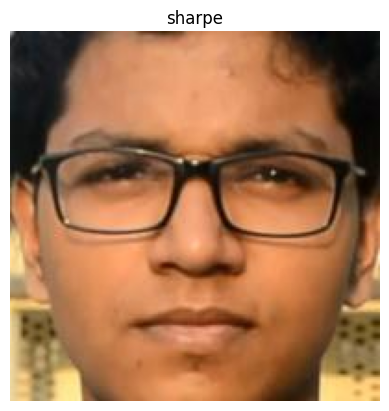

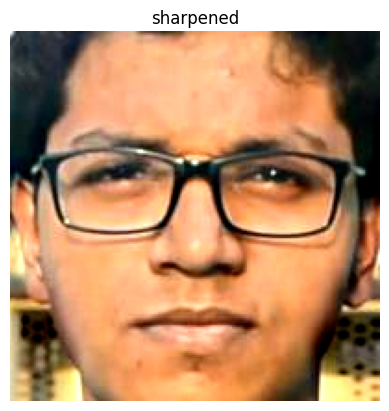

In [31]:

original=cv.imread(r"Frontal_face-20260910T120648Z-1-001\Frontal_face\3.jpg")
original_rgb=cv.cvtColor(original,cv.COLOR_BGR2RGB)

plt.imshow(original_rgb)
plt.title("sharpe")
plt.axis("off")
plt.show()

original_rgb=original_rgb.astype(np.float32)

blurred=cv.imread(r"Blurry_face-20260910T120637Z-1-001\Blurry_face\3.jpg")
blurred_rgb=cv.cvtColor(blurred,cv.COLOR_BGR2RGB)
blurred_rgb=blurred_rgb.astype(np.float32)


a=0.7
sharp_image=original_rgb+a*(original_rgb-blurred_rgb)
sharp_image=np.clip(sharp_image,0,255).astype(np.uint8)




plt.imshow(sharp_image)
plt.title("sharpened")
plt.axis("off")
plt.show()


### Detect the edges from both the sharp and the sharpened images using 
### 1. Sobel edge detection methods.


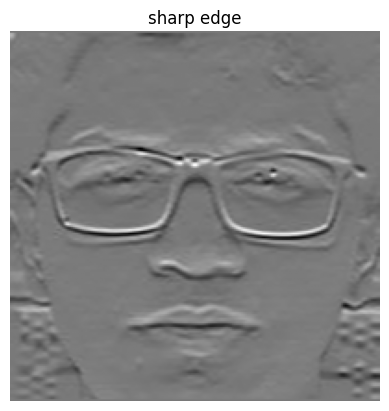

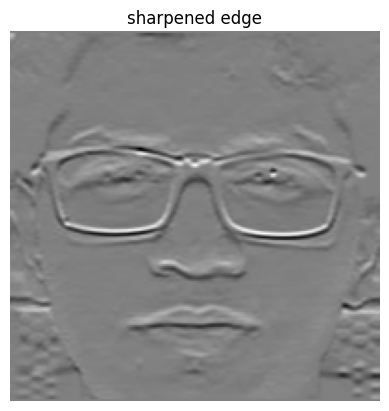

In [34]:



sobel_kernel=np.array([[1,2,1],
                       [0,0,0],
                       [-1,-2,-1]]).astype(np.float32)

original_grey=cv.cvtColor(original_rgb,cv.COLOR_RGB2GRAY)
original_edge=cv.filter2D(original_grey,cv.CV_32F,sobel_kernel)
plt.imshow(original_edge, cmap="gray")
plt.title("sharp edge")
plt.axis("off")
plt.show()

sharpened_grey=cv.cvtColor(sharp_image,cv.COLOR_RGB2GRAY)
sharpened_edge=cv.filter2D(sharpened_grey,cv.CV_32F,sobel_kernel)
plt.imshow(sharpened_edge, cmap="gray")
plt.title("sharpened edge")
plt.axis("off")
plt.show()



### 2.Canny edge detection methods

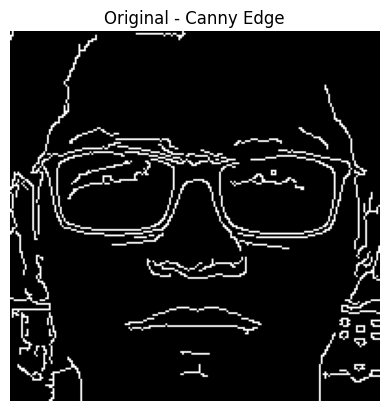

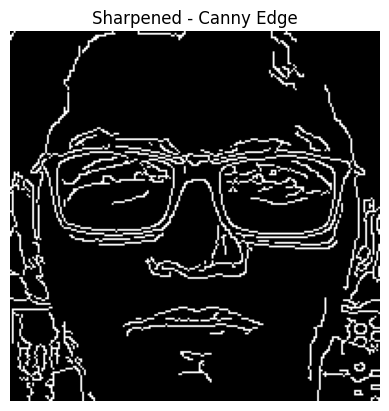

In [33]:
original_canny = cv.Canny(
    original_grey.astype(np.uint8),
    100,
    200
)

plt.imshow(original_canny, cmap="gray")
plt.title("Original - Canny Edge")
plt.axis("off")
plt.show()



sharpened_canny = cv.Canny(
    sharpened_grey,
    100,
    200
)

plt.imshow(sharpened_canny, cmap="gray")
plt.title("Sharpened - Canny Edge")
plt.axis("off")
plt.show()


### Compare the performance of the edge detection. (Find the proper metric for comparing
### the edge detection performance).

In [37]:
import numpy as np

original_sobel = np.abs(original_edge)
sharpened_sobel = np.abs(sharpened_edge)

original_sobel_binary = original_sobel > 100
sharpened_sobel_binary = sharpened_sobel > 100


original_canny_binary = original_canny > 0
sharpened_canny_binary = sharpened_canny > 0



original_sobel_density = np.mean(original_sobel_binary) * 100
sharpened_sobel_density = np.mean(sharpened_sobel_binary) * 100

original_canny_density = np.mean(original_canny_binary) * 100
sharpened_canny_density = np.mean(sharpened_canny_binary) * 100


print("\n--- Edge Detection Comparison ---")

print(f"Original + Sobel    : {original_sobel_density:.2f}%")
print(f"Sharpened + Sobel   : {sharpened_sobel_density:.2f}%")
print(f"Original + Canny    : {original_canny_density:.2f}%")
print(f"Sharpened + Canny   : {sharpened_canny_density:.2f}%")


--- Edge Detection Comparison ---
Original + Sobel    : 10.09%
Sharpened + Sobel   : 16.33%
Original + Canny    : 6.79%
Sharpened + Canny   : 9.69%
